# Курсова робота

In [1]:
!pip install pmdarima entsoe-py statsmodels scikit-learn prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.9 MB/s eta 0:00:00:00:01


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from entsoe import EntsoePandasClient
from kaggle_secrets import UserSecretsClient

# 1. ЗБЕРІГАЄМО ключ у змінну api_key
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("ENTSOE_TOKEN")




# 2. ПЕРЕДАЄМО цю змінну в клієнт
client = EntsoePandasClient(api_key=api_key)

# 3. СТВОРЮЄМО папку 'data', щоб уникнути помилки при збереженні файлів
os.makedirs('data', exist_ok=True)

country_code = 'FR'

start_normal = pd.Timestamp('2017-01-01', tz='Europe/Paris')
end_normal = pd.Timestamp('2020-01-01', tz='Europe/Paris')

start_crisis = pd.Timestamp('2020-01-01', tz='Europe/Paris')
end_crisis = pd.Timestamp('2023-01-01', tz='Europe/Paris')

print("Завантажуємо стабільні дані Франції (2017-2019)...")
try:
    df_normal = client.query_load(country_code, start=start_normal, end=end_normal)
    # ENTSO-E може повертати Series замість DataFrame, перетворюємо безпечно
    if isinstance(df_normal, pd.Series):
        df_normal = df_normal.to_frame(name='Energy_Consumption')
    else:
        df_normal.columns = ['Energy_Consumption']

    df_normal.to_csv('data/fr_energy_normal.csv')
    print(f"Успіх! Записів: {len(df_normal)}")
    print(f"Пропусків (NaN): {df_normal['Energy_Consumption'].isna().sum()}")
except Exception as e:
    print(f"Помилка: {e}\n")

print("\nЗавантажуємо кризові дані Франції (2020-2022)...")
try:
    df_crisis = client.query_load(country_code, start=start_crisis, end=end_crisis)
    if isinstance(df_crisis, pd.Series):
        df_crisis = df_crisis.to_frame(name='Energy_Consumption')
    else:
        df_crisis.columns = ['Energy_Consumption']

    df_crisis.to_csv('data/fr_energy_crisis.csv')
    print(f"Успіх! Записів: {len(df_crisis)}")
    print(f"Пропусків (NaN): {df_crisis['Energy_Consumption'].isna().sum()}")
except Exception as e:
    print(f"Помилка: {e}")

Завантажуємо стабільні дані Франції (2017-2019)...
Успіх! Записів: 26234
Пропусків (NaN): 0

Завантажуємо кризові дані Франції (2020-2022)...
Успіх! Записів: 26270
Пропусків (NaN): 0


### Виправляємо дані

In [3]:
def clean_and_prepare(file_path):
    # Завантаження
    df = pd.read_csv(file_path, index_col=0)
    df.index = pd.to_datetime(df.index, utc=True)

    # 1. Видалення дублікатів (важливо для стабільності індексу)
    df = df[~df.index.duplicated(keep='first')]

    # 2. Створення регулярної сітки (Hourly Frequency)
    # Змінено 'H' на 'h' для сумісності з новими версіями pandas
    df = df.asfreq('h')

    # 3. Лінійна інтерполяція
    df['Energy_Consumption'] = df['Energy_Consumption'].interpolate(method='linear', limit_direction='both')

    return df

# Очищуємо наші основні змінні
df_normal = clean_and_prepare('data/fr_energy_normal.csv')
df_crisis = clean_and_prepare('data/fr_energy_crisis.csv')

print("Дані очищені: дублікати видалені, часова сітка відновлена, пропуски інтерпольовані.")
print(f"Частота ряду: {df_normal.index.freq}")

Дані очищені: дублікати видалені, часова сітка відновлена, пропуски інтерпольовані.
Частота ряду: <Hour>


In [6]:
import pmdarima as pm

# Використовуємо той самий період
train_full_year = df_normal.loc['2018-04-01':'2019-03-31', 'Energy_Consumption']

print("Запуск розширеного пошуку (Kaggle Edition)...")

model_ultra = pm.auto_arima(
    train_full_year,
    seasonal=True,
    m=24,
    start_p=0, start_q=2,
    start_P=1, start_Q=1,
    max_p=3, max_q=3,   # Збільшили
    max_P=2, max_Q=2,   # Збільшили (сезонна пам'ять на 2 дні)
    stepwise=True,      # Залишимо True для початку, щоб не чекати вічність
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\n--- Нові найкращі параметри після розширення ---")
print(model_ultra.summary())

Запуск розширеного пошуку (Kaggle Edition)...
Performing stepwise search to minimize aic
 ARIMA(0,1,2)(1,0,1)[24] intercept   : AIC=139238.973, Time=45.51 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=159763.049, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=15.92 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=147991.333, Time=17.32 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=159761.051, Time=0.06 sec
 ARIMA(0,1,2)(0,0,1)[24] intercept   : AIC=147593.490, Time=17.80 sec
 ARIMA(0,1,2)(1,0,0)[24] intercept   : AIC=140737.212, Time=17.16 sec
 ARIMA(0,1,2)(2,0,1)[24] intercept   : AIC=144164.399, Time=158.04 sec
 ARIMA(0,1,2)(1,0,2)[24] intercept   : AIC=142526.010, Time=206.67 sec
 ARIMA(0,1,2)(0,0,0)[24] intercept   : AIC=153747.258, Time=0.51 sec
 ARIMA(0,1,2)(0,0,2)[24] intercept   : AIC=144935.202, Time=70.94 sec
 ARIMA(0,1,2)(2,0,0)[24] intercept   : AIC=140337.517, Time=124.50 sec
 ARIMA(0,1,2)(2,0,2)[24] intercept   : AIC=inf, Time=239.33 sec
 ARIMA(0,1,1)(

1. Навчання SARIMA (0,1,2)x(1,0,1,24)...
2. Навчання Prophet...


19:13:16 - cmdstanpy - INFO - Chain [1] start processing
19:13:20 - cmdstanpy - INFO - Chain [1] done processing



=== РЕЗУЛЬТАТИ ЕТАЛОННОГО ТЕСТУ (Квітень 2019) ===
--- SARIMA ---
MAPE: 36.97%
MAE:  19186.49 MW
RMSE: 20483.70 MW

--- Prophet ---
MAPE: 49.54%
MAE:  25070.76 MW
RMSE: 27400.37 MW



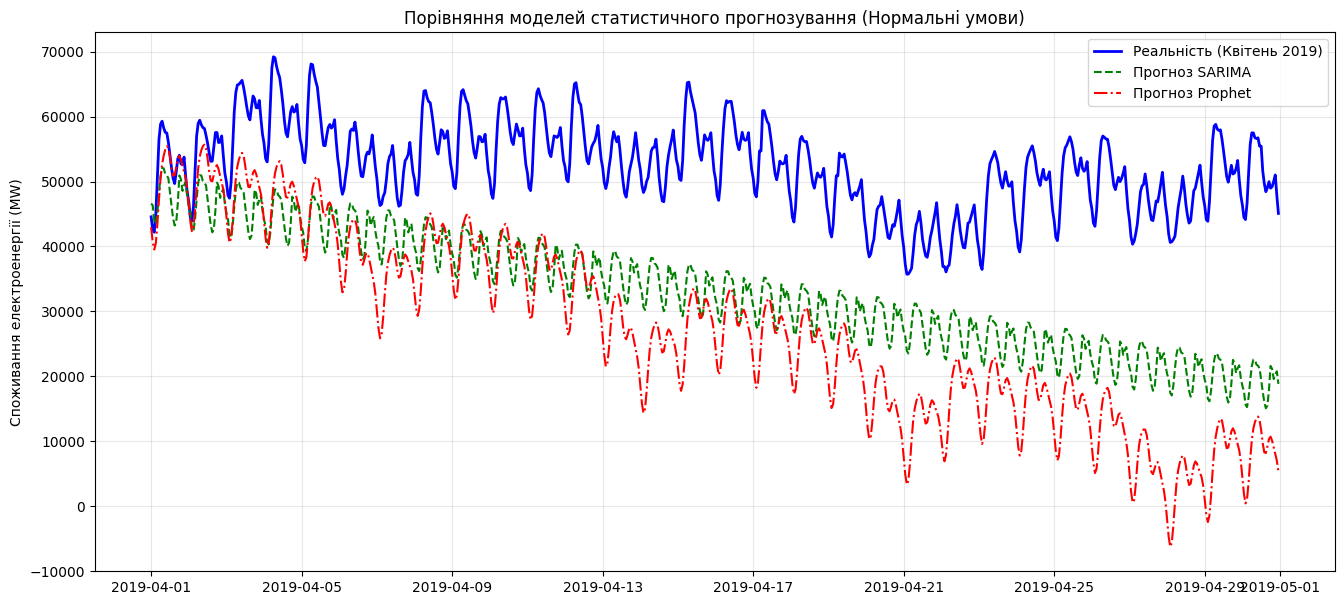

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. Підготовка даних
train_2018 = df_normal.loc['2018-04-01':'2019-03-31', 'Energy_Consumption']
test_2019  = df_normal.loc['2019-04-01':'2019-04-30', 'Energy_Consumption']

print("1. Навчання SARIMA (0,1,2)x(1,0,1,24)...")
model_sarima = SARIMAX(train_2018, order=(0, 1, 2), seasonal_order=(1, 0, 1, 24),
                       enforce_stationarity=False, enforce_invertibility=False)
fit_sarima = model_sarima.fit(disp=False, method='powell', low_memory=True)
forecast_sarima = fit_sarima.get_forecast(steps=len(test_2019)).predicted_mean

print("2. Навчання Prophet...")
df_prophet_train = train_2018.reset_index()
df_prophet_train.columns = ['ds', 'y']
df_prophet_train['ds'] = df_prophet_train['ds'].dt.tz_localize(None)

model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
model_prophet.fit(df_prophet_train)

future = model_prophet.make_future_dataframe(periods=len(test_2019), freq='h')
forecast_prophet_full = model_prophet.predict(future)
forecast_prophet = forecast_prophet_full.tail(len(test_2019))['yhat'].values

# 3. Функція оцінки
def print_metrics(name, actual, predicted):
    mape = mean_absolute_percentage_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"--- {name} ---")
    print(f"MAPE: {mape:.2%}")
    print(f"MAE:  {mae:.2f} MW")
    print(f"RMSE: {rmse:.2f} MW\n")

print("\n=== РЕЗУЛЬТАТИ ЕТАЛОННОГО ТЕСТУ (Квітень 2019) ===")
print_metrics("SARIMA", test_2019.values, forecast_sarima.values)
print_metrics("Prophet", test_2019.values, forecast_prophet)

# 4. Візуалізація
plt.figure(figsize=(16, 7))
plt.plot(test_2019.index, test_2019.values, label='Реальність (Квітень 2019)', color='blue', linewidth=2)
plt.plot(test_2019.index, forecast_sarima.values, label='Прогноз SARIMA', color='green', linestyle='--')
plt.plot(test_2019.index, forecast_prophet, label='Прогноз Prophet', color='red', linestyle='-.')
plt.title('Порівняння моделей статистичного прогнозування (Нормальні умови)')
plt.ylabel('Споживання електроенергії (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Похибка SARIMA на 1 добу наперед (Day-Ahead): 9.16%


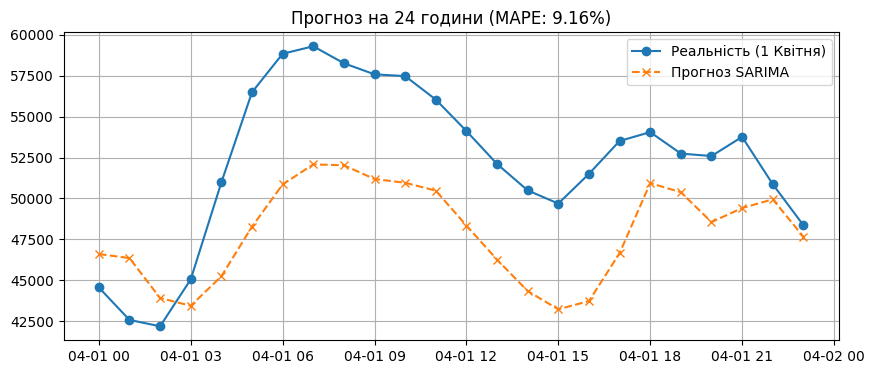

In [8]:
# Відрізаємо лише першу добу квітня 2019 (24 години)
test_24h = test_2019.iloc[:24]

# Просимо SARIMA спрогнозувати лише 24 кроки
forecast_sarima_24h = fit_sarima.get_forecast(steps=24).predicted_mean

# Рахуємо MAPE
mape_24h = mean_absolute_percentage_error(test_24h, forecast_sarima_24h)

print(f"Похибка SARIMA на 1 добу наперед (Day-Ahead): {mape_24h:.2%}")

# Швидкий графік
plt.figure(figsize=(10, 4))
plt.plot(test_24h.index, test_24h.values, label='Реальність (1 Квітня)', marker='o')
plt.plot(test_24h.index, forecast_sarima_24h.values, label='Прогноз SARIMA', linestyle='--', marker='x')
plt.title(f'Прогноз на 24 години (MAPE: {mape_24h:.2%})')
plt.legend()
plt.grid(True)
plt.show()

Ініціалізація базової моделі (це займе близько хвилини)...
Починаємо симуляцію диспетчерського прогнозу на 30 днів...
Пройдено днів: 5 з 30...
Пройдено днів: 10 з 30...
Пройдено днів: 15 з 30...
Пройдено днів: 20 з 30...
Пройдено днів: 25 з 30...
Пройдено днів: 30 з 30...

--- Фінальний результат Ковзного Вікна ---
Середній MAPE за весь квітень (Day-Ahead): 5.33%


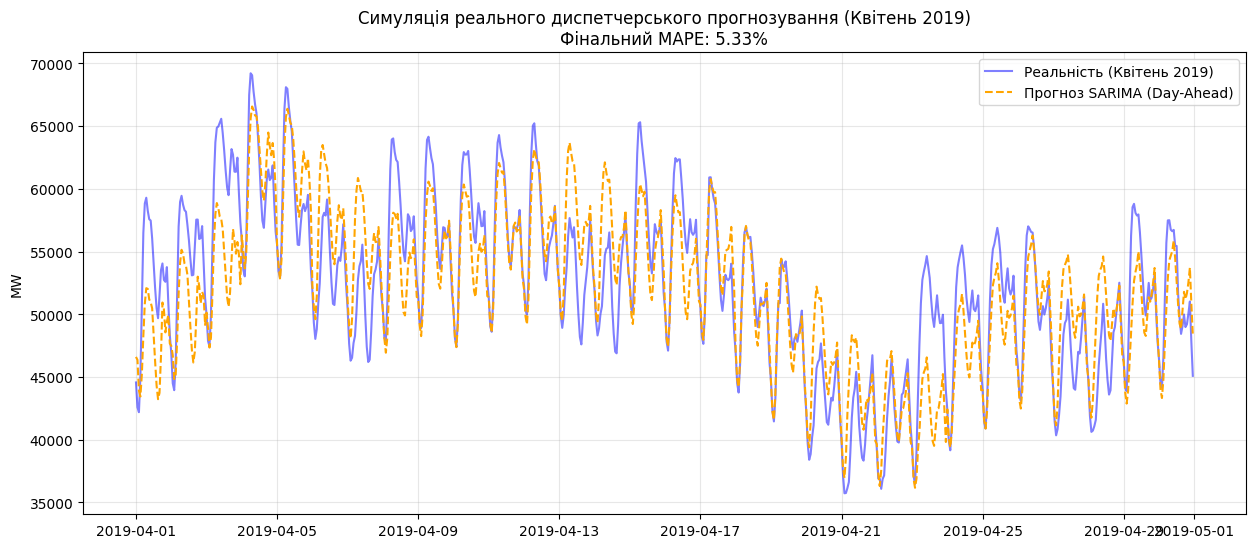

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# 1. Переконаймося, що дані готові
train_2018 = df_normal.loc['2018-04-01':'2019-03-31', 'Energy_Consumption']
test_2019  = df_normal.loc['2019-04-01':'2019-04-30', 'Energy_Consumption']

print("Ініціалізація базової моделі (це займе близько хвилини)...")
base_model = SARIMAX(train_2018, order=(0, 1, 2), seasonal_order=(1, 0, 1, 24),
                     enforce_stationarity=False, enforce_invertibility=False)
res = base_model.fit(disp=False, method='powell', low_memory=True)

predictions = []
test_days = len(test_2019) // 24

print(f"Починаємо симуляцію диспетчерського прогнозу на {test_days} днів...")

for i in range(test_days):
    # Крок 1: Прогнозуємо наступну добу (24 години)
    fc = res.forecast(steps=24)
    predictions.extend(fc)
    
    # Крок 2: Отримуємо реальні дані за цю добу, які "надійшли" по факту
    true_24h = test_2019.iloc[i*24 : (i+1)*24]
    
    # Крок 3: Оновлюємо внутрішню пам'ять моделі новими даними
    res = res.append(true_24h, refit=False)
    
    if (i + 1) % 5 == 0:
        print(f"Пройдено днів: {i + 1} з {test_days}...")

# 2. Формуємо результати
forecast_rolling = pd.Series(predictions, index=test_2019.index[:len(predictions)])
mape_rolling = mean_absolute_percentage_error(test_2019.iloc[:len(predictions)], forecast_rolling)

print(f"\n--- Фінальний результат Ковзного Вікна ---")
print(f"Середній MAPE за весь квітень (Day-Ahead): {mape_rolling:.2%}")

# 3. Візуалізація
plt.figure(figsize=(15, 6))
plt.plot(test_2019.index, test_2019.values, label='Реальність (Квітень 2019)', color='blue', alpha=0.5)
plt.plot(forecast_rolling.index, forecast_rolling.values, label='Прогноз SARIMA (Day-Ahead)', color='orange', linestyle='--')
plt.title(f'Симуляція реального диспетчерського прогнозування (Квітень 2019)\nФінальний MAPE: {mape_rolling:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ініціалізація базової моделі на даних 2019-2020 років...
Починаємо симуляцію диспетчера для Квітня 2020 (днів: 30)...
Пройдено кризових днів: 5 з 30...
Пройдено кризових днів: 10 з 30...
Пройдено кризових днів: 15 з 30...
Пройдено кризових днів: 20 з 30...
Пройдено кризових днів: 25 з 30...
Пройдено кризових днів: 30 з 30...

--- Фінальний результат Стрес-тесту ---
Середній MAPE за Квітень 2020 (Day-Ahead): 3.47%


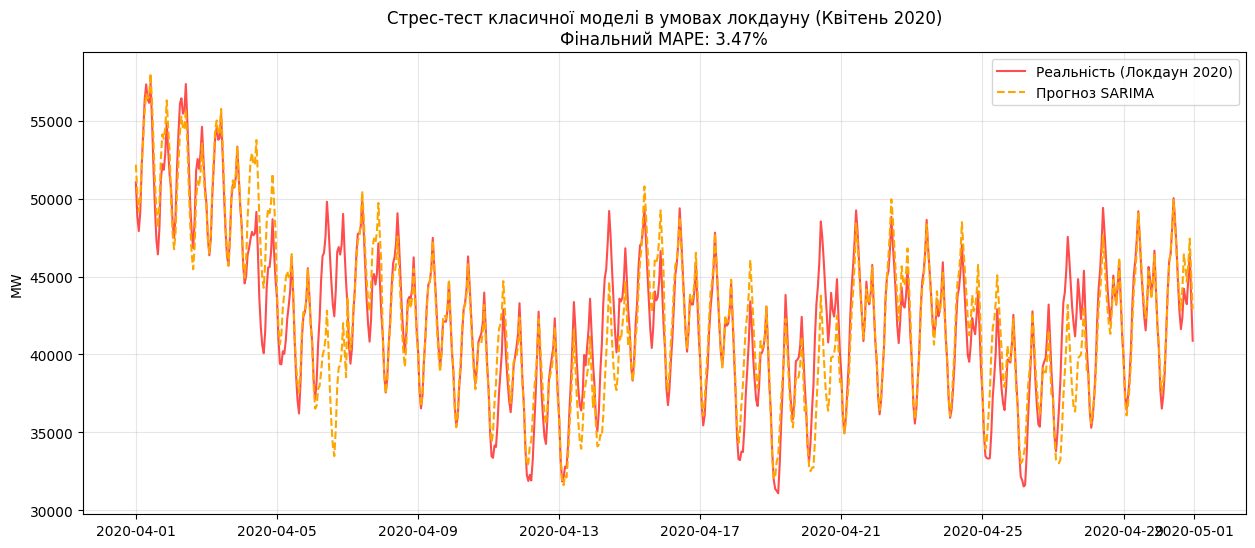

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# 1. Виділяємо дані з масиву кризового періоду
# Навчання: рівно один рік до локдауну (Квітень 2019 - Березень 2020)
train_crisis = df_crisis.loc['2019-04-01':'2020-03-31', 'Energy_Consumption']

# Тест: Квітень 2020 (місяць суворого карантину)
test_crisis = df_crisis.loc['2020-04-01':'2020-04-30', 'Energy_Consumption']

print("Ініціалізація базової моделі на даних 2019-2020 років...")
model_crisis = SARIMAX(train_crisis, order=(0, 1, 2), seasonal_order=(1, 0, 1, 24),
                     enforce_stationarity=False, enforce_invertibility=False)
res_crisis = model_crisis.fit(disp=False, method='powell', low_memory=True)

predictions_crisis = []
test_days_crisis = len(test_crisis) // 24

print(f"Починаємо симуляцію диспетчера для Квітня 2020 (днів: {test_days_crisis})...")

for i in range(test_days_crisis):
    # Крок 1: Прогнозуємо наступні 24 години
    fc = res_crisis.forecast(steps=24)
    predictions_crisis.extend(fc)
    
    # Крок 2: Отримуємо реальні дані обваленого споживання за цю добу
    true_24h = test_crisis.iloc[i*24 : (i+1)*24]
    
    # Крок 3: Оновлюємо внутрішню пам'ять новими фактами
    res_crisis = res_crisis.append(true_24h, refit=False)
    
    if (i + 1) % 5 == 0:
        print(f"Пройдено кризових днів: {i + 1} з {test_days_crisis}...")

# 2. Формуємо результати
forecast_rolling_crisis = pd.Series(predictions_crisis, index=test_crisis.index[:len(predictions_crisis)])
mape_rolling_crisis = mean_absolute_percentage_error(test_crisis.iloc[:len(predictions_crisis)], forecast_rolling_crisis)

print(f"\n--- Фінальний результат Стрес-тесту ---")
print(f"Середній MAPE за Квітень 2020 (Day-Ahead): {mape_rolling_crisis:.2%}")

# 3. Візуалізація
plt.figure(figsize=(15, 6))
plt.plot(test_crisis.index, test_crisis.values, label='Реальність (Локдаун 2020)', color='red', alpha=0.7)
plt.plot(forecast_rolling_crisis.index, forecast_rolling_crisis.values, label='Прогноз SARIMA', color='orange', linestyle='--')
plt.title(f'Стрес-тест класичної моделі в умовах локдауну (Квітень 2020)\nФінальний MAPE: {mape_rolling_crisis:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Навчаємо 'чисту' модель для сліпого тесту...
Генеруємо сліпий прогноз на 720 годин наперед (Квітень 2020)...

--- Результат Сліпого Стрес-тесту ---
MAPE (Квітень 2020, наосліп): 20.65%


Text(0.5, 1.0, 'Сліпе прогнозування під час структурного зсуву (Локдаун 2020)\nФінальний MAPE: 20.65%')

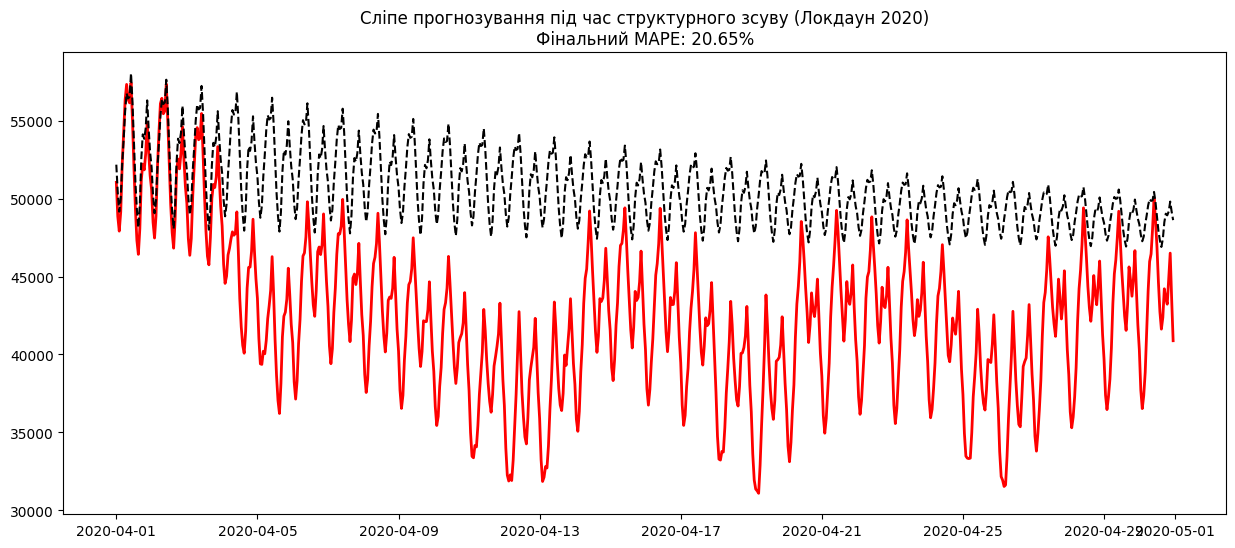

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# 1. Готуємо чисті дані (Навчання закінчується 31 березня 2020)
train_crisis = df_crisis.loc['2019-04-01':'2020-03-31', 'Energy_Consumption']
test_crisis  = df_crisis.loc['2020-04-01':'2020-04-30', 'Energy_Consumption']

print("Навчаємо 'чисту' модель для сліпого тесту...")
model_blind_crisis = SARIMAX(train_crisis, order=(0, 1, 2), seasonal_order=(1, 0, 1, 24),
                             enforce_stationarity=False, enforce_invertibility=False)

# Навчання
fit_blind_crisis = model_blind_crisis.fit(disp=False, method='powell', low_memory=True)

print("Генеруємо сліпий прогноз на 720 годин наперед (Квітень 2020)...")
# 2. Робимо прогноз наосліп
forecast_blind_crisis = fit_blind_crisis.get_forecast(steps=len(test_crisis)).predicted_mean

# 3. Рахуємо похибку
mape_blind_crisis = mean_absolute_percentage_error(test_crisis, forecast_blind_crisis)

print(f"\n--- Результат Сліпого Стрес-тесту ---")
print(f"MAPE (Квітень 2020, наосліп): {mape_blind_crisis:.2%}")

# 4. Візуалізація катастрофи
plt.figure(figsize=(15, 6))
plt.plot(test_crisis.index, test_crisis.values, label='Реальність (Локдаун 2020)', color='red', linewidth=2)
plt.plot(test_crisis.index, forecast_blind_crisis.values, label='Сліпий прогноз SARIMA', color='black', linestyle='--')
plt.title(f'Сліпе прогнозування під час структурного зсуву (Локдаун 2020)\nФінальний MAPE: {mape_blind_crisis:.2%}')

Навчаємо модель виключно на докризових даних...
Генеруємо прогноз на березень 2020 (зустріч з Чорним лебедем)...

--- Справжній стрес-тест (Чорний лебідь) ---
MAPE: 19.05%


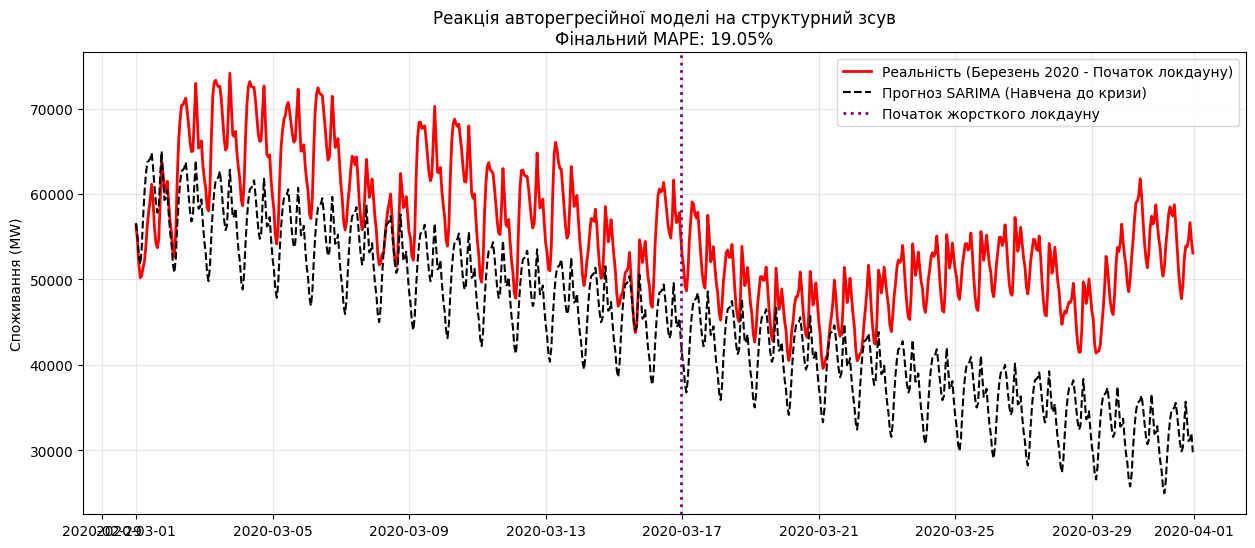

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# 1. Формуємо кристально чисту вибірку (Ніякого локдауну в навчанні)
# Навчаємо модель до 29 лютого 2020 року
train_pure_normal = df_crisis.loc['2019-03-01':'2020-02-29', 'Energy_Consumption']

# Тестуємо на березні 2020 року (17 березня стається обвал)
test_black_swan = df_crisis.loc['2020-03-01':'2020-03-31', 'Energy_Consumption']

print("Навчаємо модель виключно на докризових даних...")
model_swan = SARIMAX(train_pure_normal, order=(0, 1, 2), seasonal_order=(1, 0, 1, 24),
                     enforce_stationarity=False, enforce_invertibility=False)

fit_swan = model_swan.fit(disp=False, method='powell', low_memory=True)

print("Генеруємо прогноз на березень 2020 (зустріч з Чорним лебедем)...")
forecast_swan = fit_swan.get_forecast(steps=len(test_black_swan)).predicted_mean

mape_swan = mean_absolute_percentage_error(test_black_swan, forecast_swan)

print(f"\n--- Справжній стрес-тест (Чорний лебідь) ---")
print(f"MAPE: {mape_swan:.2%}")

# Візуалізація моменту зламу
plt.figure(figsize=(15, 6))
plt.plot(test_black_swan.index, test_black_swan.values, label='Реальність (Березень 2020 - Початок локдауну)', color='red', linewidth=2)
plt.plot(test_black_swan.index, forecast_swan.values, label='Прогноз SARIMA (Навчена до кризи)', color='black', linestyle='--')

# Додаємо вертикальну лінію початку локдауну
plt.axvline(pd.Timestamp('2020-03-17', tz='Europe/Paris'), color='purple', linestyle=':', linewidth=2, label='Початок жорсткого локдауну')

plt.title(f'Реакція авторегресійної моделі на структурний зсув\nФінальний MAPE: {mape_swan:.2%}')
plt.ylabel('Споживання (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Машине навчання

Підготовка даних

In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Починаємо підготовку даних для нейромереж...")

# 1. Розділяємо дані на тренувальні та тестові для ML
# Візьмемо для навчання ML весь 2018 рік, а тестувати будемо на квітні 2019
train_data_ml = df_normal.loc['2018-04-01':'2019-03-31', ['Energy_Consumption']]
test_data_ml = df_normal.loc['2019-04-01':'2019-04-30', ['Energy_Consumption']]

# 2. Ініціалізуємо та навчаємо MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Навчаємо (fit) тільки на train, а застосовуємо (transform) до обох
train_scaled = scaler.fit_transform(train_data_ml)
test_scaled = scaler.transform(test_data_ml)

print("Дані успішно масштабовано в діапазон [0, 1].")

# 3. Функція для створення "ковзного вікна"
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0]) # Беремо seq_length годин історії
        y.append(data[i + seq_length, 0])     # Прогнозуємо наступну 1 годину
    return np.array(X), np.array(y)

# Встановлюємо розмір вікна. Наприклад, 24 години (дивимося на добу назад)
# Для LSTM пізніше можна буде зробити 168 (тиждень назад)
SEQUENCE_LENGTH = 24

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)

print("\n--- Результати нарізки вікон ---")
print(f"Розмірність X_train: {X_train.shape} -> (Кількість зразків, Годин у вікні)")
print(f"Розмірність y_train: {y_train.shape} -> (Кількість цільових значень)")
print(f"Приклад першого X_train (перші 5 значень): {X_train[0][:5]}")

Починаємо підготовку даних для нейромереж...
Дані успішно масштабовано в діапазон [0, 1].

--- Результати нарізки вікон ---
Розмірність X_train: (8736, 24) -> (Кількість зразків, Годин у вікні)
Розмірність y_train: (8736,) -> (Кількість цільових значень)
Приклад першого X_train (перші 5 значень): [0.43208702 0.37881208 0.34752562 0.34980524 0.37195527]


Будуємо архітектуру Багатошарового перцептрона (MLP)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-18 20:09:23.207169: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)


Починаємо навчання моделі (30 епох)...
Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0441 - val_loss: 0.0026
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.8459e-04 - val_loss: 0.0013
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4315e-04 - val_loss: 0.0014
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0084e-04 - val_loss: 0.0011
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1450e-04 - val_loss: 0.0010
Epoch 8/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8294e-04 - val_loss: 0.0010
Epoch 9/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1776e-04 - val_loss: 9.5019e-04
Epoch 10/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6704e-04 - val_loss: 9.4306e-04
Epoch 11/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.

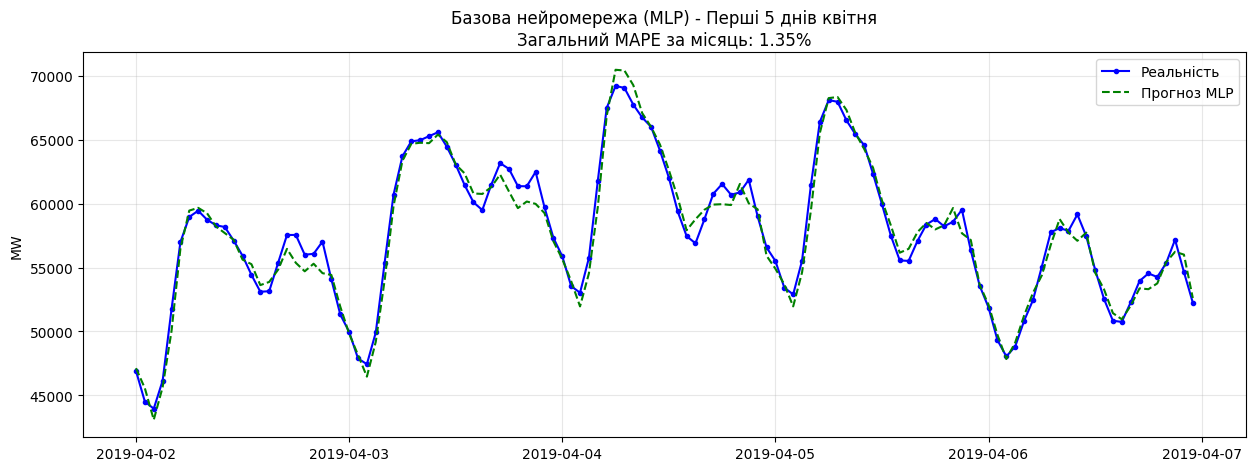

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

print("Будуємо архітектуру Багатошарового перцептрона (MLP)...")

# 1. Створення архітектури моделі
model_mlp = Sequential([
    # Вхідний шар: очікує вектор довжиною 24 (SEQUENCE_LENGTH)
    Dense(64, activation='relu', input_shape=(SEQUENCE_LENGTH,)),
    # Прихований шар
    Dense(32, activation='relu'),
    # Вихідний шар: 1 нейрон (наш прогноз на наступну годину)
    Dense(1)
])

# Компіляція моделі (використовуємо оптимізатор Adam та функцію втрат MSE)
model_mlp.compile(optimizer='adam', loss='mse')

model_mlp.summary()

print("\nПочинаємо навчання моделі (30 епох)...")
# 2. Навчання моделі
# validation_split=0.1 означає, що 10% даних відкладається для перевірки перенавчання
history = model_mlp.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# 3. Прогнозування на тестовій вибірці (Квітень 2019)
print("\nГенеруємо прогноз на квітень 2019...")
y_pred_scaled = model_mlp.predict(X_test)

# 4. ОБЕРНЕНЕ МАСШТАБУВАННЯ (Повертаємося до Мегаватів)
# reshape(-1, 1) потрібен, бо scaler очікує двовимірний масив
y_pred_mw = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_mw = scaler.inverse_transform(y_test.reshape(-1, 1))

# 5. Оцінка результатів
mape_mlp = mean_absolute_percentage_error(y_test_mw, y_pred_mw)
mae_mlp = mean_absolute_error(y_test_mw, y_pred_mw)
rmse_mlp = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))

print("\n=== Результати MLP (Квітень 2019) ===")
print(f"MAPE: {mape_mlp:.2%}")
print(f"MAE:  {mae_mlp:.2f} MW")
print(f"RMSE: {rmse_mlp:.2f} MW")

# 6. Візуалізація
# Візьмемо для графіка перші 5 днів (120 годин), щоб було чітко видно структуру
часовий_індекс = test_data_ml.index[SEQUENCE_LENGTH:SEQUENCE_LENGTH+120]

plt.figure(figsize=(15, 5))
plt.plot(часовий_індекс, y_test_mw[:120], label='Реальність', color='blue', marker='.')
plt.plot(часовий_індекс, y_pred_mw[:120], label='Прогноз MLP', color='green', linestyle='--')
plt.title(f'Базова нейромережа (MLP) - Перші 5 днів квітня\nЗагальний MAPE за місяць: {mape_mlp:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Готуємо дані для багатокрокового прогнозу (24 -> 24)...
Будуємо архітектуру моделі...
Починаємо навчання моделі (30 епох)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Навчання завершено успішно!
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

=== Чесний результат MLP (Day-Ahead, Квітень 2019) ===
MAPE: 4.81%
RMSE: 3298.56 MW


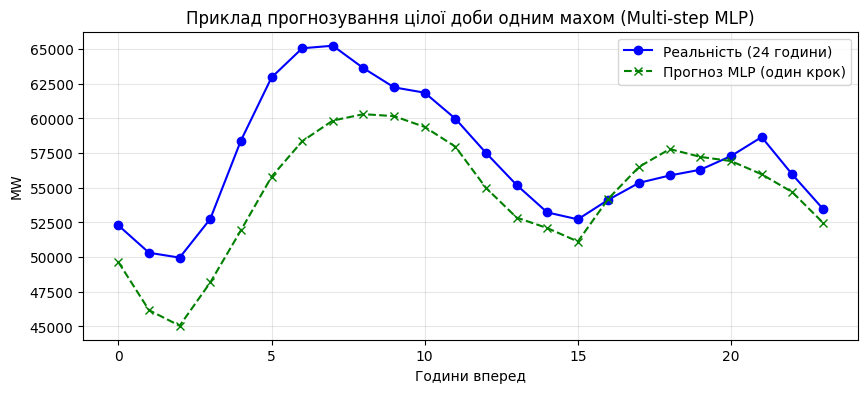

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

print("Готуємо дані для багатокрокового прогнозу (24 -> 24)...")

# 1. Оновлена функція нарізки вікон
def create_sequences_multistep(data, seq_length, out_length):
    X, y = [], []
    # Ми маємо зупинитися раніше, щоб вистачило даних для останнього y
    for i in range(len(data) - seq_length - out_length + 1):
        X.append(data[i : i + seq_length, 0])
        y.append(data[i + seq_length : i + seq_length + out_length, 0])
    return np.array(X), np.array(y)

SEQ_LEN = 24
OUT_LEN = 24

X_train_24, y_train_24 = create_sequences_multistep(train_scaled, SEQ_LEN, OUT_LEN)
X_test_24, y_test_24 = create_sequences_multistep(test_scaled, SEQ_LEN, OUT_LEN)

print("Будуємо архітектуру моделі...")
# 2. Оновлена архітектура
model_mlp_24 = Sequential([
    Dense(128, activation='relu', input_shape=(SEQ_LEN,)),
    Dense(64, activation='relu'),
    # ГОЛОВНА ЗМІНА: Вихідний шар тепер має 24 нейрони
    Dense(OUT_LEN) 
])

model_mlp_24.compile(optimizer='adam', loss='mse')

print("Починаємо навчання моделі (30 епох)...")
# 3. Навчання
history_24 = model_mlp_24.fit(
    X_train_24, y_train_24,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0 # Вимкнули логування кожної епохи для чистоти екрану
)
print("Навчання завершено успішно!")

# 4. Прогнозування
y_pred_scaled_24 = model_mlp_24.predict(X_test_24)

# 5. Складне зворотне масштабування 
# (scaler очікує 1 стовпець, тому ми сплющуємо масив, масштабуємо і повертаємо форму)
y_pred_mw_24 = scaler.inverse_transform(y_pred_scaled_24.reshape(-1, 1)).reshape(y_pred_scaled_24.shape)
y_test_mw_24 = scaler.inverse_transform(y_test_24.reshape(-1, 1)).reshape(y_test_24.shape)

# 6. Оцінка (Flatten дозволяє порівняти всі 24-годинні вікна як єдиний масив)
mape_mlp_24 = mean_absolute_percentage_error(y_test_mw_24.flatten(), y_pred_mw_24.flatten())
rmse_mlp_24 = np.sqrt(mean_squared_error(y_test_mw_24.flatten(), y_pred_mw_24.flatten()))

print("\n=== Чесний результат MLP (Day-Ahead, Квітень 2019) ===")
print(f"MAPE: {mape_mlp_24:.2%}")
print(f"RMSE: {rmse_mlp_24:.2f} MW")

# 7. Візуалізація одного довільного дня (наприклад, 10-го вікна в тестовій вибірці)
вікно = 240 # Приблизно 10-й день квітня

plt.figure(figsize=(10, 4))
plt.plot(range(24), y_test_mw_24[вікно], label='Реальність (24 години)', marker='o', color='blue')
plt.plot(range(24), y_pred_mw_24[вікно], label='Прогноз MLP (один крок)', linestyle='--', marker='x', color='green')
plt.title('Приклад прогнозування цілої доби одним махом (Multi-step MLP)')
plt.xlabel('Години вперед')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Генеруємо сліпий прогноз MLP на 30 днів (720 годин) авторегресійним методом...

--- Результат Сліпого Тесту MLP (Квітень 2019) ---
MAPE: 12.73%


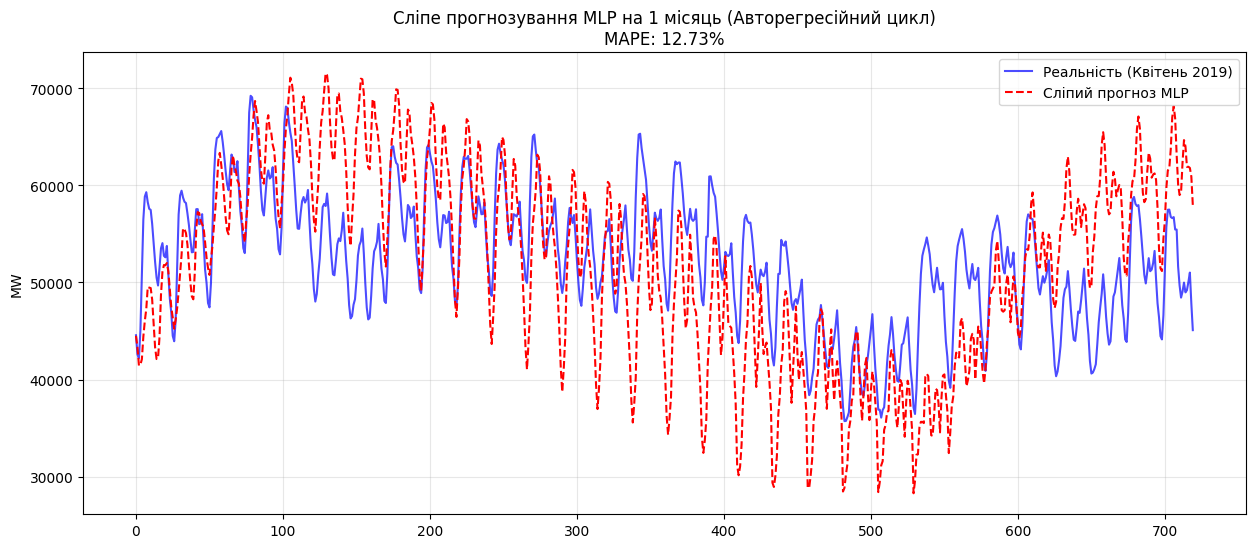

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

print("Генеруємо сліпий прогноз MLP на 30 днів (720 годин) авторегресійним методом...")

# 1. Беремо останні 24 години навчальної вибірки (31 березня 2019) як стартову точку
last_24h = train_scaled[-24:]
current_input = last_24h.reshape(1, 24) # Формат для Keras: (batch_size, sequence_length)

blind_predictions_scaled = []

# 2. Авторегресійний цикл (Прогноз стає новим входом)
for _ in range(30):
    # Прогнозуємо наступну добу (24 години)
    pred_24h = model_mlp_24.predict(current_input, verbose=0)
    blind_predictions_scaled.append(pred_24h[0]) # Зберігаємо результат
    
    # Оновлюємо вхід: тепер наш власний прогноз стає історією для наступного кроку
    current_input = pred_24h 

# 3. Збираємо всі 30 днів у єдиний масив (720 годин)
blind_predictions_scaled = np.array(blind_predictions_scaled).flatten()

# 4. Зворотне масштабування (повертаємо мегавати)
blind_predictions_mw = scaler.inverse_transform(blind_predictions_scaled.reshape(-1, 1)).flatten()

# Беремо рівно 30 днів реальності (720 годин) для порівняння
actual_april_2019_mw = scaler.inverse_transform(test_scaled[:720]).flatten() 

# 5. Оцінка
mape_mlp_blind = mean_absolute_percentage_error(actual_april_2019_mw, blind_predictions_mw)

print(f"\n--- Результат Сліпого Тесту MLP (Квітень 2019) ---")
print(f"MAPE: {mape_mlp_blind:.2%}")

# 6. Візуалізація сліпоти
plt.figure(figsize=(15, 6))
plt.plot(actual_april_2019_mw, label='Реальність (Квітень 2019)', color='blue', alpha=0.7)
plt.plot(blind_predictions_mw, label='Сліпий прогноз MLP', color='red', linestyle='--')
plt.title(f'Сліпе прогнозування MLP на 1 місяць (Авторегресійний цикл)\nMAPE: {mape_mlp_blind:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Готуємо дані для Тесту 3 (MLP під час Локдауну)...
Будуємо та навчаємо 'кризову' модель MLP (30 епох)...
Навчання завершено!
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Результат MLP Day-Ahead (Локдаун, Квітень 2020) ---
MAPE: 6.71%


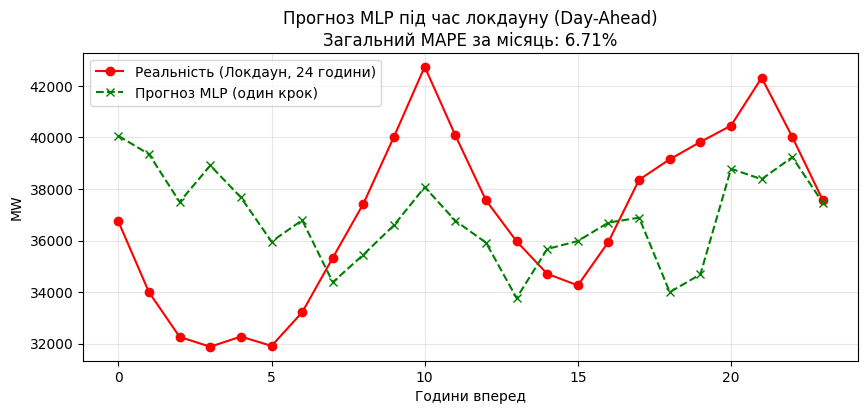

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

print("Готуємо дані для Тесту 3 (MLP під час Локдауну)...")

# 1. Виділяємо дані
train_crisis_df = df_crisis.loc['2019-04-01':'2020-03-31', ['Energy_Consumption']]
test_crisis_df  = df_crisis.loc['2020-04-01':'2020-04-30', ['Energy_Consumption']]

# 2. Масштабування
scaler_crisis = MinMaxScaler(feature_range=(0, 1))
train_crisis_scaled = scaler_crisis.fit_transform(train_crisis_df)
test_crisis_scaled = scaler_crisis.transform(test_crisis_df)

# 3. Нарізаємо вікна
X_train_cr, y_train_cr = create_sequences_multistep(train_crisis_scaled, SEQ_LEN, OUT_LEN)
X_test_cr, y_test_cr = create_sequences_multistep(test_crisis_scaled, SEQ_LEN, OUT_LEN)

print("Будуємо та навчаємо 'кризову' модель MLP (30 епох)...")
# 4. Архітектура (додано Input(shape) щоб уникнути попередження Keras)
model_mlp_crisis = Sequential([
    Input(shape=(SEQ_LEN,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(OUT_LEN)
])

model_mlp_crisis.compile(optimizer='adam', loss='mse')

# Навчання
model_mlp_crisis.fit(
    X_train_cr, y_train_cr,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("Навчання завершено!")

# 5. Генеруємо прогноз (Day-Ahead)
y_pred_cr_scaled = model_mlp_crisis.predict(X_test_cr)

# 6. Зворотне масштабування
y_pred_cr_mw = scaler_crisis.inverse_transform(y_pred_cr_scaled.reshape(-1, 1)).reshape(y_pred_cr_scaled.shape)
y_test_cr_mw = scaler_crisis.inverse_transform(y_test_cr.reshape(-1, 1)).reshape(y_test_cr.shape)

# 7. Оцінка
mape_mlp_crisis = mean_absolute_percentage_error(y_test_cr_mw.flatten(), y_pred_cr_mw.flatten())

print(f"\n--- Результат MLP Day-Ahead (Локдаун, Квітень 2020) ---")
print(f"MAPE: {mape_mlp_crisis:.2%}")

# 8. ВІЗУАЛІЗАЦІЯ
вікно = 240 # Приблизно 10-й день квітня

plt.figure(figsize=(10, 4))
plt.plot(range(24), y_test_cr_mw[вікно], label='Реальність (Локдаун, 24 години)', marker='o', color='red')
plt.plot(range(24), y_pred_cr_mw[вікно], label='Прогноз MLP (один крок)', linestyle='--', marker='x', color='green')
plt.title(f'Прогноз MLP під час локдауну (Day-Ahead)\nЗагальний MAPE за місяць: {mape_mlp_crisis:.2%}')
plt.xlabel('Години вперед')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Готуємо дані для Тесту 4 (MLP - Зустріч з Чорним лебедем)...
Будуємо та навчаємо модель MLP на докризових даних (30 епох)...
Навчання завершено! Починаємо авторегресійний сліпий прогноз...

--- Результат Сліпого Тесту MLP (Чорний лебідь, Березень 2020) ---
MAPE: 17.37%


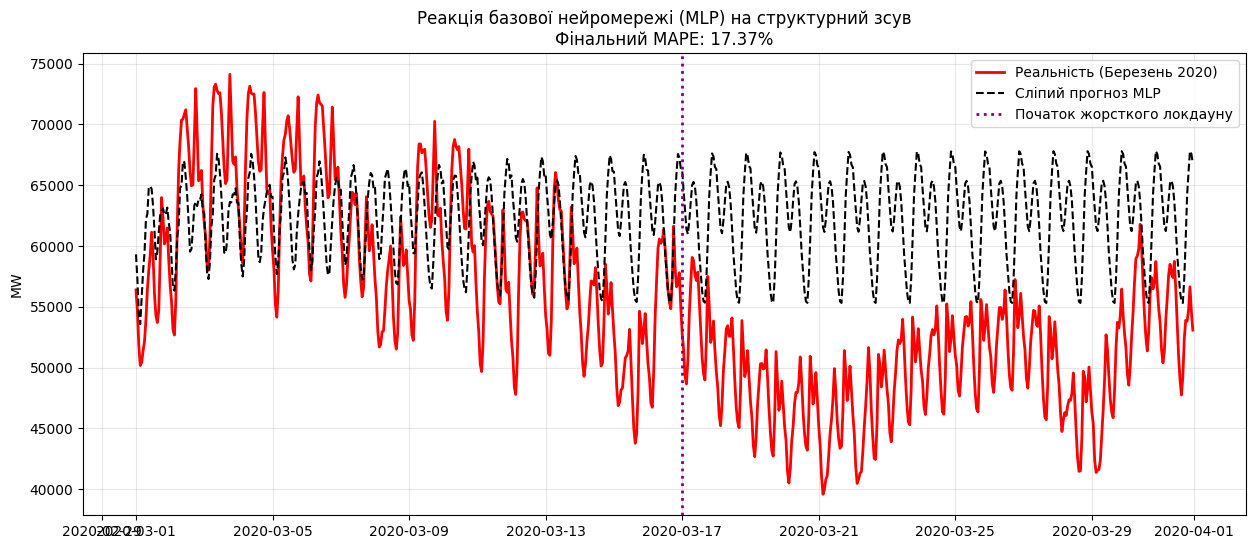

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

print("Готуємо дані для Тесту 4 (MLP - Зустріч з Чорним лебедем)...")

# 1. Формуємо кристально чисту вибірку
train_swan_df = df_crisis.loc['2019-03-01':'2020-02-29', ['Energy_Consumption']]
test_swan_df = df_crisis.loc['2020-03-01':'2020-03-31', ['Energy_Consumption']]

# 2. Масштабування
scaler_swan = MinMaxScaler(feature_range=(0, 1))
train_swan_scaled = scaler_swan.fit_transform(train_swan_df)
test_swan_scaled = scaler_swan.transform(test_swan_df)

# 3. Нарізаємо вікна для навчання (24 -> 24)
X_train_sw, y_train_sw = create_sequences_multistep(train_swan_scaled, SEQ_LEN, OUT_LEN)

print("Будуємо та навчаємо модель MLP на докризових даних (30 епох)...")
# 4. Архітектура
model_mlp_swan = Sequential([
    Input(shape=(SEQ_LEN,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(OUT_LEN)
])
model_mlp_swan.compile(optimizer='adam', loss='mse')

# Навчання
model_mlp_swan.fit(
    X_train_sw, y_train_sw,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("Навчання завершено! Починаємо авторегресійний сліпий прогноз...")

# 5. Авторегресійний цикл на 31 день (Березень має 31 день = 744 години)
last_24h_sw = train_swan_scaled[-24:]
current_input_sw = last_24h_sw.reshape(1, 24)

blind_predictions_sw_scaled = []

for _ in range(31):
    pred_24h_sw = model_mlp_swan.predict(current_input_sw, verbose=0)
    blind_predictions_sw_scaled.append(pred_24h_sw[0])
    current_input_sw = pred_24h_sw

# 6. Збираємо 31 день у єдиний масив (744 години)
blind_predictions_sw_scaled = np.array(blind_predictions_sw_scaled).flatten()

# Зворотне масштабування
blind_predictions_sw_mw = scaler_swan.inverse_transform(blind_predictions_sw_scaled.reshape(-1, 1)).flatten()
actual_march_2020_mw = scaler_swan.inverse_transform(test_swan_scaled[:744]).flatten()

# 7. Оцінка
mape_mlp_swan = mean_absolute_percentage_error(actual_march_2020_mw, blind_predictions_sw_mw)

print(f"\n--- Результат Сліпого Тесту MLP (Чорний лебідь, Березень 2020) ---")
print(f"MAPE: {mape_mlp_swan:.2%}")

# 8. Візуалізація моменту зламу
# Беремо індекси часу для осі X
index_march = test_swan_df.index[:744]

plt.figure(figsize=(15, 6))
plt.plot(index_march, actual_march_2020_mw, label='Реальність (Березень 2020)', color='red', linewidth=2)
plt.plot(index_march, blind_predictions_sw_mw, label='Сліпий прогноз MLP', color='black', linestyle='--')

# Знаходимо індекс для 17 березня (початок локдауну)
lockdown_start = index_march[16 * 24]
plt.axvline(lockdown_start, color='purple', linestyle=':', linewidth=2, label='Початок жорсткого локдауну')

plt.title(f'Реакція базової нейромережі (MLP) на структурний зсув\nФінальний MAPE: {mape_mlp_swan:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Генеруємо сліпий прогноз MLP на 30 днів (Квітень 2020 - Локдаун)...

--- Результат Сліпого Тесту MLP (Локдаун, Квітень 2020) ---
MAPE: 45.96%


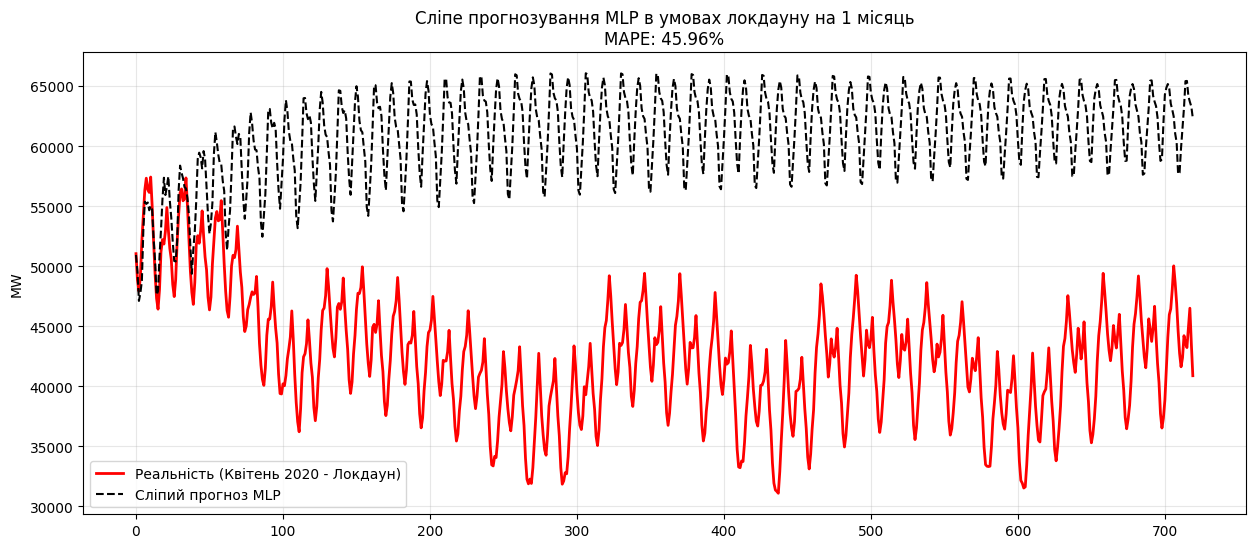

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

print("Генеруємо сліпий прогноз MLP на 30 днів (Квітень 2020 - Локдаун)...")

# 1. Беремо останні 24 години березня 2020 року як стартову точку
last_24h_crisis = train_crisis_scaled[-24:]
current_input_cr = last_24h_crisis.reshape(1, 24)

blind_predictions_cr_scaled = []

# 2. Авторегресійний цикл на 30 днів (720 годин)
for _ in range(30):
    pred_24h_cr = model_mlp_crisis.predict(current_input_cr, verbose=0)
    blind_predictions_cr_scaled.append(pred_24h_cr[0])
    current_input_cr = pred_24h_cr

# 3. Збираємо 30 днів у єдиний масив
blind_predictions_cr_scaled = np.array(blind_predictions_cr_scaled).flatten()

# 4. Зворотне масштабування
blind_predictions_cr_mw = scaler_crisis.inverse_transform(blind_predictions_cr_scaled.reshape(-1, 1)).flatten()
actual_april_2020_mw = scaler_crisis.inverse_transform(test_crisis_scaled[:720]).flatten()

# 5. Оцінка
mape_mlp_blind_crisis = mean_absolute_percentage_error(actual_april_2020_mw, blind_predictions_cr_mw)

print(f"\n--- Результат Сліпого Тесту MLP (Локдаун, Квітень 2020) ---")
print(f"MAPE: {mape_mlp_blind_crisis:.2%}")

# 6. Візуалізація
plt.figure(figsize=(15, 6))
plt.plot(actual_april_2020_mw, label='Реальність (Квітень 2020 - Локдаун)', color='red', linewidth=2)
plt.plot(blind_predictions_cr_mw, label='Сліпий прогноз MLP', color='black', linestyle='--')
plt.title(f'Сліпе прогнозування MLP в умовах локдауну на 1 місяць\nMAPE: {mape_mlp_blind_crisis:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

LSTM

In [6]:
import numpy as np

print("--- Етап 1: Відновлення даних та підготовка 3D-тензорів для LSTM ---")

# 1. Відновлюємо функцію нарізки (на випадок, якщо середовище її забуло)
def create_sequences_multistep(data, seq_length, out_length):
    X, y = [], []
    for i in range(len(data) - seq_length - out_length + 1):
        X.append(data[i : i + seq_length, 0])
        y.append(data[i + seq_length : i + seq_length + out_length, 0])
    return np.array(X), np.array(y)

SEQ_LEN = 24
OUT_LEN = 24

# 2. Створюємо базові 2D масиви (припускаючи, що train_scaled та test_scaled існують)
print("Нарізаємо вікна 24->24...")
X_train_24, y_train_24 = create_sequences_multistep(train_scaled, SEQ_LEN, OUT_LEN)
X_test_24, y_test_24 = create_sequences_multistep(test_scaled, SEQ_LEN, OUT_LEN)

# 3. Перетворення 2D у 3D шляхом додавання осі ознак (features = 1)
print("Додаємо третій вимір для LSTM...")
X_train_lstm = X_train_24.reshape((X_train_24.shape[0], X_train_24.shape[1], 1))
X_test_lstm = X_test_24.reshape((X_test_24.shape[0], X_test_24.shape[1], 1))

print(f"Стара форма даних (для MLP): {X_train_24.shape}")
print(f"Нова форма даних (для LSTM): {X_train_lstm.shape}")
print("Дані успішно трансформовані та готові до навчання.")

--- Етап 1: Відновлення даних та підготовка 3D-тензорів для LSTM ---
Нарізаємо вікна 24->24...
Додаємо третій вимір для LSTM...
Стара форма даних (для MLP): (8713, 24)
Нова форма даних (для LSTM): (8713, 24, 1)
Дані успішно трансформовані та готові до навчання.


2026-03-21 12:27:05.637446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774096025.817600      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774096025.870103      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774096026.273492      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774096026.273538      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774096026.273541      55 computation_placer.cc:177] computation placer alr

--- Етап 2: Ініціалізація та навчання LSTM ---


I0000 00:00:1774096045.423464      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774096045.429648      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Навчання розпочато...


I0000 00:00:1774096048.606493     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


Навчання завершено успішно!

Генеруємо прогноз на тестовій вибірці...
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=== Результат LSTM Day-Ahead (Нормальні умови, Квітень 2019) ===
MAPE: 5.53%
RMSE: 3892.11 MW


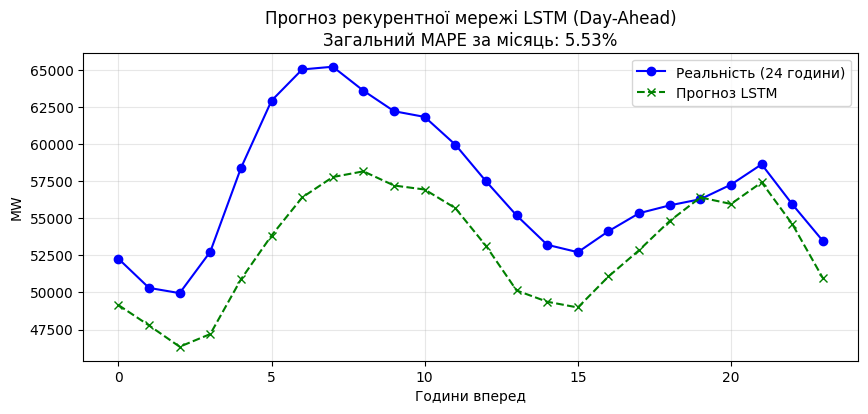

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

print("--- Етап 2: Ініціалізація та навчання LSTM ---")

# 1. Будуємо архітектуру моделі
model_lstm_24 = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    # Основний шар LSTM з 64 блоками пам'яті
    LSTM(64), 
    # Вихідний шар на 24 години
    Dense(OUT_LEN)
])

model_lstm_24.compile(optimizer='adam', loss='mse')

# 2. Навчання моделі (30 епох)
print("Навчання розпочато...")
model_lstm_24.fit(
    X_train_lstm, y_train_24,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("Навчання завершено успішно!")

# 3. Генеруємо прогноз (Day-Ahead) на Квітень 2019
print("\nГенеруємо прогноз на тестовій вибірці...")
y_pred_lstm_scaled = model_lstm_24.predict(X_test_lstm)

# 4. Зворотне масштабування
y_pred_lstm_mw = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).reshape(y_pred_lstm_scaled.shape)
y_test_mw_24 = scaler.inverse_transform(y_test_24.reshape(-1, 1)).reshape(y_test_24.shape)

# 5. Оцінка результатів
mape_lstm_24 = mean_absolute_percentage_error(y_test_mw_24.flatten(), y_pred_lstm_mw.flatten())
rmse_lstm_24 = np.sqrt(mean_squared_error(y_test_mw_24.flatten(), y_pred_lstm_mw.flatten()))

print(f"\n=== Результат LSTM Day-Ahead (Нормальні умови, Квітень 2019) ===")
print(f"MAPE: {mape_lstm_24:.2%}")
print(f"RMSE: {rmse_lstm_24:.2f} MW")

# 6. Візуалізація
вікно = 240 # Приблизно 10-й день квітня

plt.figure(figsize=(10, 4))
plt.plot(range(24), y_test_mw_24[вікно], label='Реальність (24 години)', marker='o', color='blue')
plt.plot(range(24), y_pred_lstm_mw[вікно], label='Прогноз LSTM', linestyle='--', marker='x', color='green')
plt.title(f'Прогноз рекурентної мережі LSTM (Day-Ahead)\nЗагальний MAPE за місяць: {mape_lstm_24:.2%}')
plt.xlabel('Години вперед')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Ініціалізація ПОКРАЩЕНОЇ моделі LSTM ---
Починаємо розумне навчання (може зупинитися раніше за 100 епох)...
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0588 - val_loss: 0.0114
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0158 - val_loss: 0.0103
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0131 - val_loss: 0.0101
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112 - val_loss: 0.0102
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0104 - val_loss: 0.0099
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0097 - val_loss: 0.0093
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 9/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0080 - val_loss: 0.0083
Epoch 10/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0073 - val_loss: 0.0096
Epoch 11/100
123

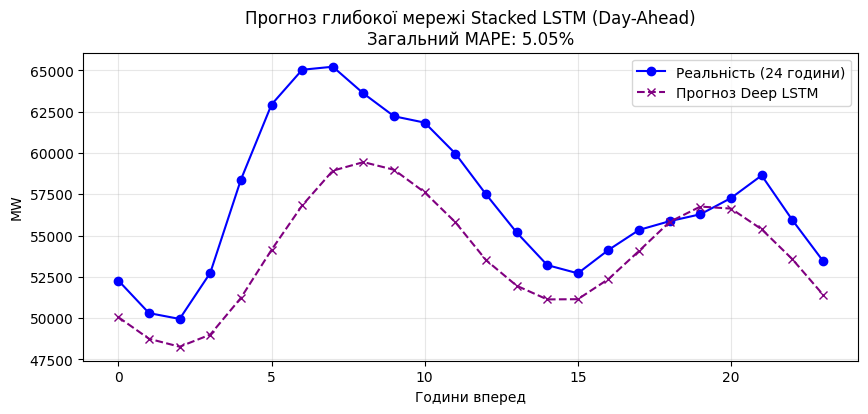

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

print("--- Ініціалізація ПОКРАЩЕНОЇ моделі LSTM ---")

# 1. Будуємо глибоку архітектуру (Stacked LSTM)
model_lstm_deep = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    
    # Перший шар LSTM (return_sequences=True обов'язково для передачі даних на наступний LSTM)
    LSTM(128, return_sequences=True),
    Dropout(0.2), # Вимикаємо 20% нейронів для боротьби з перенавчанням
    
    # Другий шар LSTM
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    
    # Вихідний шар
    Dense(OUT_LEN)
])

model_lstm_deep.compile(optimizer='adam', loss='mse')

# 2. Налаштування ранньої зупинки (Early Stopping)
# patience=10 означає, що ми чекаємо 10 епох без покращень, перш ніж зупинитись
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 3. Навчання з новими правилами (даємо до 100 епох)
print("Починаємо розумне навчання (може зупинитися раніше за 100 епох)...")
history_deep = model_lstm_deep.fit(
    X_train_lstm, y_train_24,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1 # Включимо логування, щоб бачити, на якій епосі вона зупиниться
)

# 4. Прогнозування та зворотне масштабування
print("\nГенеруємо прогноз на Квітень 2019...")
y_pred_deep_scaled = model_lstm_deep.predict(X_test_lstm)

y_pred_deep_mw = scaler.inverse_transform(y_pred_deep_scaled.reshape(-1, 1)).reshape(y_pred_deep_scaled.shape)
# y_test_mw_24 вже є в пам'яті з минулих кроків

# 5. Оцінка
mape_lstm_deep = mean_absolute_percentage_error(y_test_mw_24.flatten(), y_pred_deep_mw.flatten())
rmse_lstm_deep = np.sqrt(mean_squared_error(y_test_mw_24.flatten(), y_pred_deep_mw.flatten()))

print(f"\n=== Результат ПОКРАЩЕНОЇ LSTM (Day-Ahead, Квітень 2019) ===")
print(f"MAPE: {mape_lstm_deep:.2%}")
print(f"RMSE: {rmse_lstm_deep:.2f} MW")

# 6. Візуалізація
вікно = 240

plt.figure(figsize=(10, 4))
plt.plot(range(24), y_test_mw_24[вікно], label='Реальність (24 години)', marker='o', color='blue')
plt.plot(range(24), y_pred_deep_mw[вікно], label='Прогноз Deep LSTM', linestyle='--', marker='x', color='purple')
plt.title(f'Прогноз глибокої мережі Stacked LSTM (Day-Ahead)\nЗагальний MAPE: {mape_lstm_deep:.2%}')
plt.xlabel('Години вперед')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Генеруємо сліпий прогноз Deep LSTM на 30 днів (720 годин) авторегресійним методом...

--- Результат Сліпого Тесту Deep LSTM (Квітень 2019) ---
MAPE: 16.48%


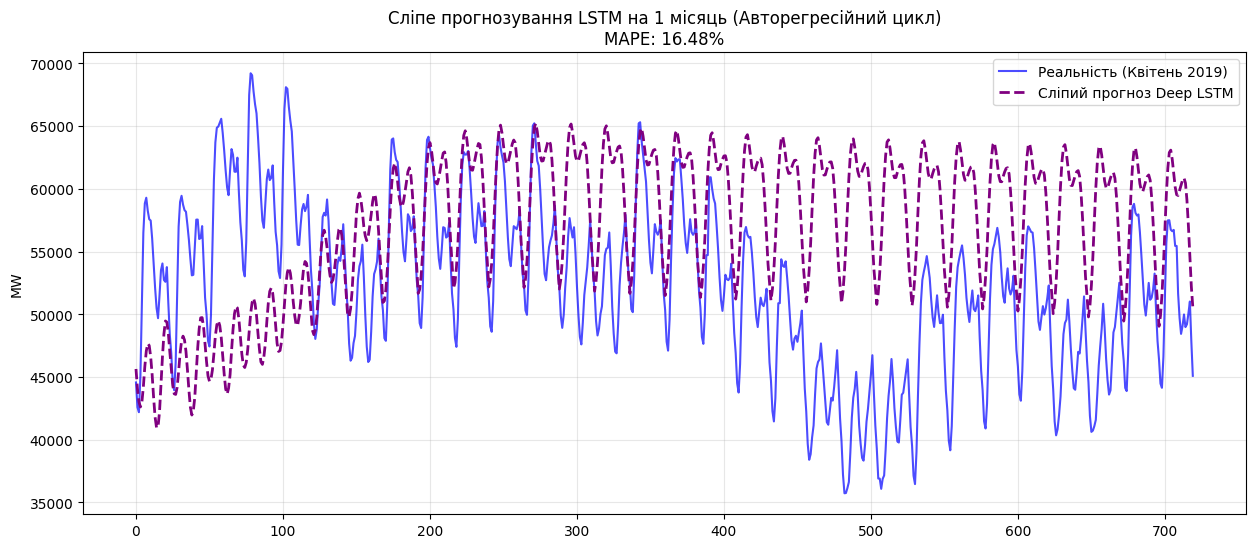

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

print("Генеруємо сліпий прогноз Deep LSTM на 30 днів (720 годин) авторегресійним методом...")

# 1. Беремо останні 24 години навчальної вибірки (31 березня 2019)
last_24h_lstm = train_scaled[-24:]

# 2. Форматуємо у 3D-тензор для Keras: (batch_size, sequence_length, features)
current_input_lstm = last_24h_lstm.reshape((1, 24, 1))

blind_predictions_lstm_scaled = []

# 3. Авторегресійний цикл
for _ in range(30):
    # Прогнозуємо наступну добу
    pred_24h_lstm = model_lstm_deep.predict(current_input_lstm, verbose=0)
    
    # Зберігаємо результат (перший і єдиний елемент батчу)
    blind_predictions_lstm_scaled.append(pred_24h_lstm[0])
    
    # Оновлюємо вхід: прогноз стає новою історією, одразу робимо його 3D
    current_input_lstm = pred_24h_lstm.reshape((1, 24, 1))

# 4. Збираємо 30 днів у єдиний масив (720 годин)
blind_predictions_lstm_scaled = np.array(blind_predictions_lstm_scaled).flatten()

# 5. Зворотне масштабування
blind_predictions_lstm_mw = scaler.inverse_transform(blind_predictions_lstm_scaled.reshape(-1, 1)).flatten()
actual_april_2019_mw = scaler.inverse_transform(test_scaled[:720]).flatten()

# 6. Оцінка
mape_lstm_blind = mean_absolute_percentage_error(actual_april_2019_mw, blind_predictions_lstm_mw)

print(f"\n--- Результат Сліпого Тесту Deep LSTM (Квітень 2019) ---")
print(f"MAPE: {mape_lstm_blind:.2%}")

# 7. Візуалізація
plt.figure(figsize=(15, 6))
plt.plot(actual_april_2019_mw, label='Реальність (Квітень 2019)', color='blue', alpha=0.7)
plt.plot(blind_predictions_lstm_mw, label='Сліпий прогноз Deep LSTM', color='purple', linestyle='--', linewidth=2)
plt.title(f'Сліпе прогнозування LSTM на 1 місяць (Авторегресійний цикл)\nMAPE: {mape_lstm_blind:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Етап 1: Відновлення та підготовка кризових даних ---
Форма кризових даних для LSTM готова: (2138, 24, 1)

--- Етап 2: Ініціалізація та навчання 'кризової' LSTM ---
Навчання на кризових даних розпочато (до 100 епох)...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1544 - val_loss: 0.0095
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0355 - val_loss: 0.0091
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0290 - val_loss: 0.0092
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0271 - val_loss: 0.0091
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0261 - val_loss: 0.0094
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0249 - val_loss: 0.0096
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0243 - val_loss: 0.0085
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0259 - val_loss: 0.0112
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0232 - val_loss: 0.0090
Epoch 10/1

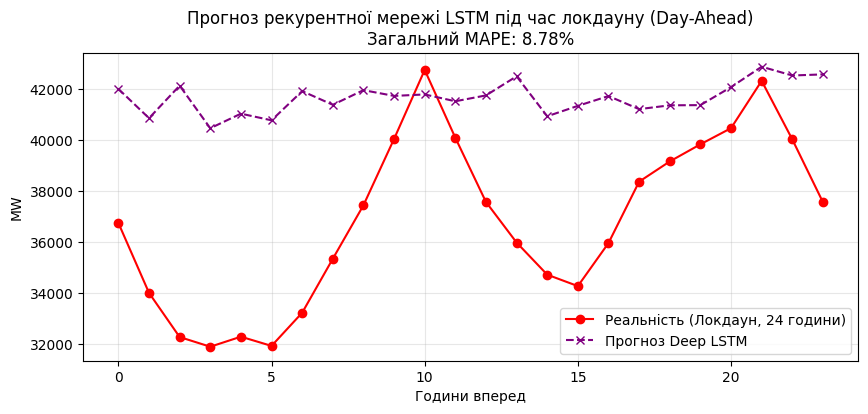

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

print("--- Етап 1: Відновлення та підготовка кризових даних ---")

# 1. Відновлюємо функцію нарізки (на випадок повної втрати пам'яті)
def create_sequences_multistep(data, seq_length, out_length):
    X, y = [], []
    for i in range(len(data) - seq_length - out_length + 1):
        X.append(data[i : i + seq_length, 0])
        y.append(data[i + seq_length : i + seq_length + out_length, 0])
    return np.array(X), np.array(y)

SEQ_LEN = 24
OUT_LEN = 24

# 2. Заново виділяємо кризовий період (Локдаун)
train_crisis_df = df_crisis.loc['2019-04-01':'2020-03-31', ['Energy_Consumption']]
test_crisis_df  = df_crisis.loc['2020-04-01':'2020-04-30', ['Energy_Consumption']]

# 3. Заново масштабуємо
scaler_crisis = MinMaxScaler(feature_range=(0, 1))
train_crisis_scaled = scaler_crisis.fit_transform(train_crisis_df)
test_crisis_scaled = scaler_crisis.transform(test_crisis_df)

# 4. Нарізаємо вікна
X_train_cr, y_train_cr = create_sequences_multistep(train_crisis_scaled, SEQ_LEN, OUT_LEN)
X_test_cr, y_test_cr = create_sequences_multistep(test_crisis_scaled, SEQ_LEN, OUT_LEN)

# 5. Перетворюємо у 3D-тензори для LSTM
X_train_cr_lstm = X_train_cr.reshape((X_train_cr.shape[0], X_train_cr.shape[1], 1))
X_test_cr_lstm = X_test_cr.reshape((X_test_cr.shape[0], X_test_cr.shape[1], 1))

print(f"Форма кризових даних для LSTM готова: {X_train_cr_lstm.shape}")

print("\n--- Етап 2: Ініціалізація та навчання 'кризової' LSTM ---")
model_lstm_crisis = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(OUT_LEN)
])

model_lstm_crisis.compile(optimizer='adam', loss='mse')
early_stop_cr = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Навчання на кризових даних розпочато (до 100 епох)...")
history_crisis = model_lstm_crisis.fit(
    X_train_cr_lstm, y_train_cr,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_cr],
    verbose=1
)

print("\nГенеруємо прогноз на Квітень 2020 (Локдаун)...")
y_pred_cr_lstm_scaled = model_lstm_crisis.predict(X_test_cr_lstm)

# 6. Зворотне масштабування
y_pred_cr_lstm_mw = scaler_crisis.inverse_transform(y_pred_cr_lstm_scaled.reshape(-1, 1)).reshape(y_pred_cr_lstm_scaled.shape)
y_test_cr_mw = scaler_crisis.inverse_transform(y_test_cr.reshape(-1, 1)).reshape(y_test_cr.shape)

# 7. Оцінка
mape_lstm_crisis = mean_absolute_percentage_error(y_test_cr_mw.flatten(), y_pred_cr_lstm_mw.flatten())

print(f"\n=== Результат Покращеної LSTM (Day-Ahead, Локдаун Квітень 2020) ===")
print(f"MAPE: {mape_lstm_crisis:.2%}")

# 8. Візуалізація
вікно = 240 # Беремо той самий день для порівняння

plt.figure(figsize=(10, 4))
plt.plot(range(24), y_test_cr_mw[вікно], label='Реальність (Локдаун, 24 години)', marker='o', color='red')
plt.plot(range(24), y_pred_cr_lstm_mw[вікно], label='Прогноз Deep LSTM', linestyle='--', marker='x', color='purple')
plt.title(f'Прогноз рекурентної мережі LSTM під час локдауну (Day-Ahead)\nЗагальний MAPE: {mape_lstm_crisis:.2%}')
plt.xlabel('Години вперед')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Генеруємо фінальний сліпий прогноз LSTM на 30 днів (Квітень 2020 - Локдаун)...

--- Результат Сліпого Тесту LSTM (Локдаун, Квітень 2020) ---
MAPE: 26.41%


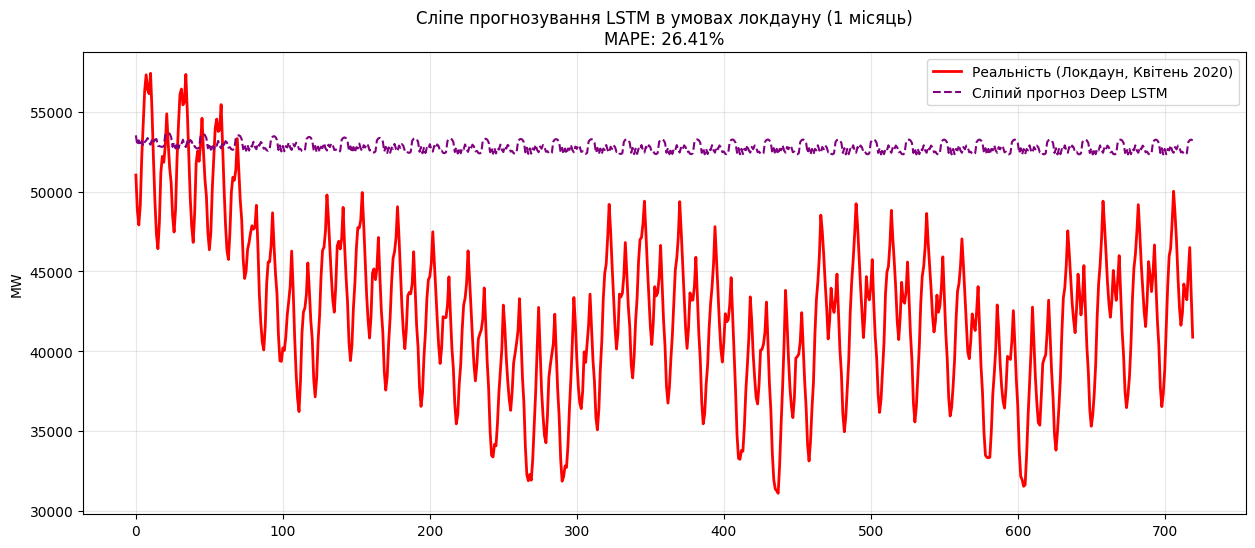

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

print("Генеруємо фінальний сліпий прогноз LSTM на 30 днів (Квітень 2020 - Локдаун)...")

# 1. Стартова точка: останні 24 години березня 2020
last_24h_cr_lstm = train_crisis_scaled[-24:]
current_input_cr_lstm = last_24h_cr_lstm.reshape((1, 24, 1))

blind_predictions_cr_lstm_scaled = []

# 2. Авторегресійний цикл
for _ in range(30):
    pred_24h_cr_lstm = model_lstm_crisis.predict(current_input_cr_lstm, verbose=0)
    blind_predictions_cr_lstm_scaled.append(pred_24h_cr_lstm[0])
    
    # Оновлюємо вхід (робимо прогноз новим входом у 3D-форматі)
    current_input_cr_lstm = pred_24h_cr_lstm.reshape((1, 24, 1))

# 3. Збираємо і розплющуємо масиви
blind_predictions_cr_lstm_scaled = np.array(blind_predictions_cr_lstm_scaled).flatten()
blind_predictions_cr_lstm_mw = scaler_crisis.inverse_transform(blind_predictions_cr_lstm_scaled.reshape(-1, 1)).flatten()
actual_april_2020_cr_mw = scaler_crisis.inverse_transform(test_crisis_scaled[:720]).flatten()

# 4. Оцінка
mape_lstm_blind_crisis = mean_absolute_percentage_error(actual_april_2020_cr_mw, blind_predictions_cr_lstm_mw)

print(f"\n--- Результат Сліпого Тесту LSTM (Локдаун, Квітень 2020) ---")
print(f"MAPE: {mape_lstm_blind_crisis:.2%}")

# 5. Візуалізація
plt.figure(figsize=(15, 6))
plt.plot(actual_april_2020_cr_mw, label='Реальність (Локдаун, Квітень 2020)', color='red', linewidth=2)
plt.plot(blind_predictions_cr_lstm_mw, label='Сліпий прогноз Deep LSTM', color='purple', linestyle='--')
plt.title(f'Сліпе прогнозування LSTM в умовах локдауну (1 місяць)\nMAPE: {mape_lstm_blind_crisis:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Етап: Ультра-тюнінг моделі LSTM ---
Навчання з динамічним темпом розпочато...

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 26: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 1e-05.
Навчання завершено!
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== Результат Тюнінгованої LSTM (Day-Ahead, Нормальні умови) ===
Попередній результат LSTM: 5.05%
Новий результат (Huber + ReduceLR): 5.27%


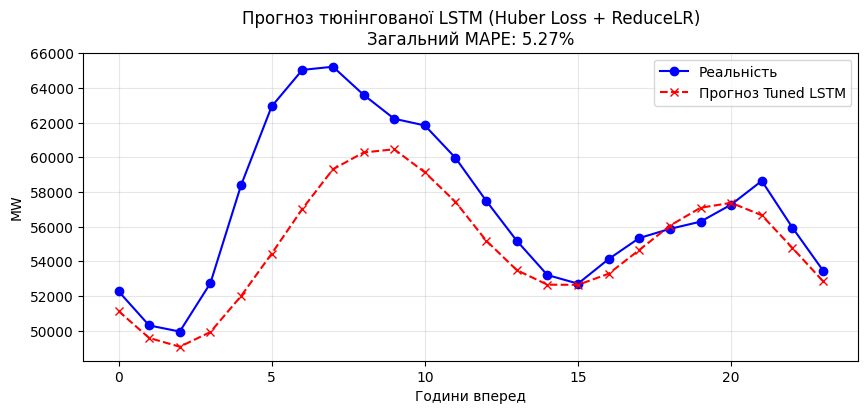

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

print("--- Етап: Ультра-тюнінг моделі LSTM ---")

# 1. Архітектура залишається глибокою
model_lstm_tuned = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(OUT_LEN)
])

# 2. ГОЛОВНА ЗМІНА 1: Використовуємо функцію втрат Huber
model_lstm_tuned.compile(optimizer='adam', loss=Huber())

# 3. ГОЛОВНА ЗМІНА 2: Динамічне зменшення темпу навчання
# factor=0.2 (зменшити швидкість у 5 разів)
# patience=5 (чекати 5 епох без покращень)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Навчання з динамічним темпом розпочато...")
history_tuned = model_lstm_tuned.fit(
    X_train_lstm, y_train_24,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=0 # Приховав базовий лог, але ReduceLROnPlateau буде писати, коли змінює швидкість
)
print("Навчання завершено!")

# 4. Генеруємо прогноз (Day-Ahead) на Квітень 2019
y_pred_tuned_scaled = model_lstm_tuned.predict(X_test_lstm)

# 5. Зворотне масштабування
y_pred_tuned_mw = scaler.inverse_transform(y_pred_tuned_scaled.reshape(-1, 1)).reshape(y_pred_tuned_scaled.shape)

# 6. Оцінка
mape_lstm_tuned = mean_absolute_percentage_error(y_test_mw_24.flatten(), y_pred_tuned_mw.flatten())

print(f"\n=== Результат Тюнінгованої LSTM (Day-Ahead, Нормальні умови) ===")
print(f"Попередній результат LSTM: 5.05%")
print(f"Новий результат (Huber + ReduceLR): {mape_lstm_tuned:.2%}")

# 7. Візуалізація
вікно = 240

plt.figure(figsize=(10, 4))
plt.plot(range(24), y_test_mw_24[вікно], label='Реальність', marker='o', color='blue')
plt.plot(range(24), y_pred_tuned_mw[вікно], label='Прогноз Tuned LSTM', linestyle='--', marker='x', color='red')
plt.title(f'Прогноз тюнінгованої LSTM (Huber Loss + ReduceLR)\nЗагальний MAPE: {mape_lstm_tuned:.2%}')
plt.xlabel('Години вперед')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()